# 1. Caricamento del dataset training.csv

In questa sezione viene caricato il dataset `training.csv`, ottenuto come sottoinsieme stratificato del dataset originale.

L'obiettivo dell'analisi esplorativa è verificare la qualità dei dati e individuare eventuali relazioni tra le feature e la variabile target `Diabetes_binary`.

In [3]:
import pandas as pd
import numpy as np

training_df = pd.read_csv("../data/training.csv")

training_df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0,1,1,25,1,0,0,1,1,1,...,0,2,0,0,0,0,7,5,8,0
1,0,1,1,29,0,0,0,1,1,1,...,0,2,0,0,0,0,10,5,6,0
2,0,0,1,25,0,0,0,1,0,1,...,0,2,0,0,0,1,12,4,6,0
3,1,0,1,28,0,0,0,0,0,0,...,0,2,0,0,0,0,8,6,5,1
4,0,1,1,29,1,0,0,1,0,1,...,0,3,5,0,0,1,6,4,8,0


# 2. Analisi preliminare del dataset

Prima di procedere con l'analisi esplorativa vengono esaminate la struttura del dataset, il numero di osservazioni e il tipo delle variabili presenti.

In [7]:
print("Shape:", training_df.shape)

training_df.info()

Shape: (50000, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   HighBP                50000 non-null  int64
 1   HighChol              50000 non-null  int64
 2   CholCheck             50000 non-null  int64
 3   BMI                   50000 non-null  int64
 4   Smoker                50000 non-null  int64
 5   Stroke                50000 non-null  int64
 6   HeartDiseaseorAttack  50000 non-null  int64
 7   PhysActivity          50000 non-null  int64
 8   Fruits                50000 non-null  int64
 9   Veggies               50000 non-null  int64
 10  HvyAlcoholConsump     50000 non-null  int64
 11  AnyHealthcare         50000 non-null  int64
 12  NoDocbcCost           50000 non-null  int64
 13  GenHlth               50000 non-null  int64
 14  MentHlth              50000 non-null  int64
 15  PhysHlth              50000 non-nu

# 3. Verifica della qualità dei dati

Prima di effettuare l'analisi esplorativa è necessario verificare che il dataset non contenga problemi evidenti che possano compromettere l'addestramento dei classificatori.

In particolare vengono analizzati:

- valori mancanti;
- osservazioni duplicate;
- range delle variabili;
- eventuali valori anomali.

## 3.1 Verifica dei valori mancanti

Verifichiamo la presenza di valori mancanti nel dataset.

Il dataset CDC originale non contiene missing values, ma è comunque buona pratica controllare eventuali anomalie introdotte durante la costruzione del file `training.csv`.

In [4]:
training_df.isnull().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

## 3.2 Verifica delle osservazioni duplicate

Controlliamo se il dataset contiene righe duplicate.

La presenza di duplicati potrebbe alterare la distribuzione delle feature e influenzare negativamente l’addestramento dei modelli.

In [5]:
duplicates = training_df.duplicated().sum()

print("Duplicati: ", duplicates)

Duplicati:  1994


I duplicati non vengono rimossi poiché rappresentano combinazioni di caratteristiche effettivamente osservate nella popolazione e non errori di acquisizione dei dati.

## 3.3 Verifica dei range delle variabili

Per ogni attributo vengono verificati i valori minimo e massimo al fine di individuare eventuali valori impossibili o palesemente errati.

In [8]:
ranges = pd.DataFrame({
    "Min": training_df.min(),
    "Max": training_df.max()
})

ranges

,Min,Max
HighBP,0,1
HighChol,0,1
CholCheck,0,1
BMI,12,98
Smoker,0,1
Stroke,0,1
HeartDiseaseorAttack,0,1
PhysActivity,0,1
Fruits,0,1
Veggies,0,1


Dall'analisi dei range non emergono valori fuori dominio.

Tutte le variabili rispettano i limiti descritti nella documentazione ufficiale del dataset UCI.

Non sono quindi state individuate osservazioni palesemente errate.

## 3.4 Ricerca di valori anomali

Per le variabili numeriche principali vengono analizzati eventuali valori anomali mediante boxplot.

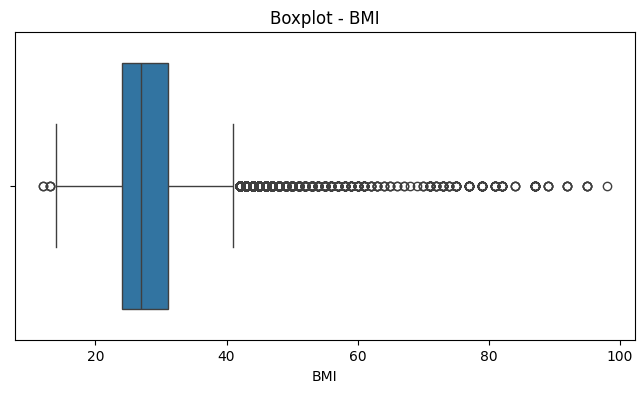

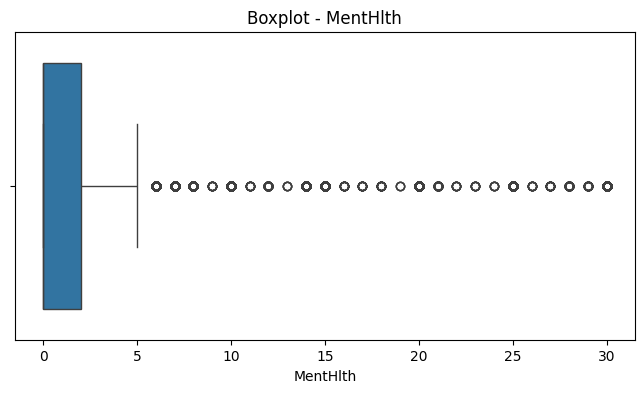

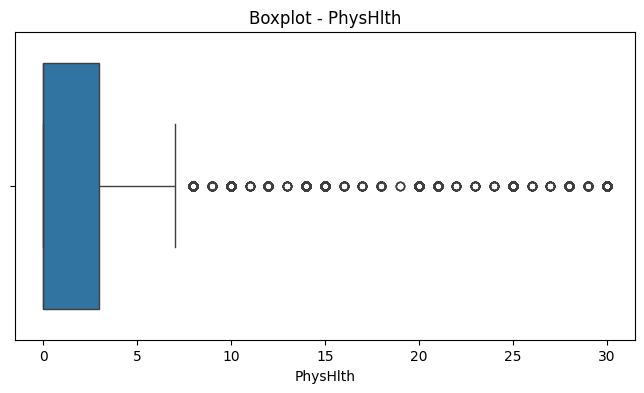

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_features = [
    "BMI",
    "MentHlth",
    "PhysHlth"
]

for feature in numeric_features:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=training_df[feature]
    )

    plt.title(f"Boxplot - {feature}")

    plt.show()

Il `BMI` presenta una distribuzione asimmetrica verso destra.

La maggior parte delle osservazioni si concentra tra valori compresi approssimativamente tra 24 e 31, mentre è presente un numero significativo di soggetti con BMI molto elevato.

I valori superiori a 40 vengono identificati dal boxplot come potenziali outlier.

Tuttavia tali osservazioni non rappresentano errori di acquisizione dei dati, poiché rientrano nei limiti previsti dalla documentazione ufficiale del dataset e corrispondono a condizioni reali di obesità severa.

La variabile `MentHlth` presenta una forte concentrazione di osservazioni nei valori più bassi.

La maggior parte degli individui dichiara pochi o nessun giorno di cattiva salute mentale nell'ultimo mese.

Sono presenti osservazioni elevate fino a 30 giorni che vengono individuate come potenziali outlier dal boxplot.

Tali valori non rappresentano anomalie, ma descrivono situazioni reali in cui un individuo ha riportato problemi di salute mentale per gran parte del mese.

Anche la variabile `PhysHlth` presenta una distribuzione fortemente asimmetrica verso destra.

La maggior parte degli individui dichiara pochi giorni di cattiva salute fisica, mentre una minoranza riporta valori elevati fino a 30 giorni.

I valori identificati come outlier dal boxplot risultano coerenti con il significato della variabile e non vengono considerati osservazioni errate.

# 4. Analisi della variabile target

Analizziamo la distribuzione della variabile `Diabetes_binary`.

L'obiettivo è verificare se le classi risultano bilanciate oppure sbilanciate, poiché tale caratteristica può influenzare significativamente la valutazione delle prestazioni dei classificatori.

## 4.1 Distribuzione delle classi

Viene calcolato il numero di osservazioni appartenenti a ciascuna classe e la relativa percentuale.

In [13]:
training_df["Diabetes_binary"].value_counts()

Diabetes_binary
0    43033
1     6967
Name: count, dtype: int64

In [16]:
training_df["Diabetes_binary"].value_counts(normalize=True) * 100

Diabetes_binary
0    86.066
1    13.934
Name: proportion, dtype: float64

Il dataset risulta quindi fortemente sbilanciato, con una netta prevalenza della classe 0 (non diabetici).  

### 4.2 Grafico a barre

Per visualizzare la distribuzione della variabile target `Diabetes_binary` è stato utilizzato un grafico a barre.

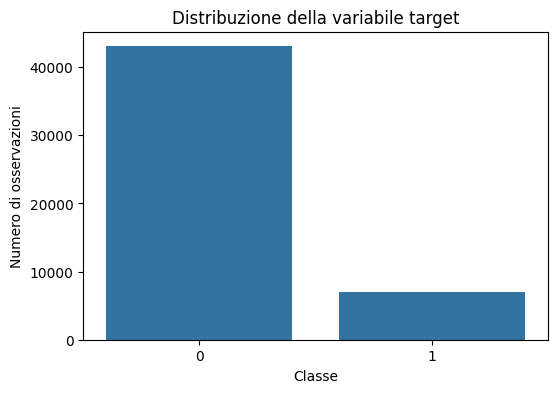

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    data=training_df,
    x="Diabetes_binary"
)

plt.title("Distribuzione della variabile target")
plt.xlabel("Classe")
plt.ylabel("Numero di osservazioni")

plt.show()


### Osservazioni

L'analisi evidenzia una forte prevalenza della classe 0 rispetto alla classe 1.

Il dataset risulta pertanto sbilanciato, con una percentuale di soggetti non diabetici significativamente superiore a quella dei soggetti diabetici.

Questa caratteristica deve essere considerata durante la valutazione dei classificatori.

In particolare, l'accuracy potrebbe non essere sufficiente per descrivere correttamente le prestazioni del modello.

Per questo motivo nelle fasi successive verranno considerate anche metriche quali:

- Precision
- Recall
- F1-Score

che risultano più informative in presenza di dataset sbilanciati.

# 5. Statistiche descrittive

Vengono calcolate le principali statistiche descrittive delle variabili presenti nel dataset.

## 5.1 Statistiche descrittive generali

Per ciascuna variabile vengono riportati:

- media;
- deviazione standard;
- valore minimo;
- primo quartile;
- mediana;
- terzo quartile;
- valore massimo.

In [19]:
training_df.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.427980,0.426400,0.962720,28.392500,0.445420,0.039660,0.097120,0.755580,0.632600,0.80908,...,0.085260,2.517440,3.180460,4.256420,0.168020,0.444140,8.035080,5.049840,6.055580,0.139340
std,0.494791,0.494558,0.189449,6.618078,0.497017,0.195161,0.296124,0.429747,0.482102,0.39303,...,0.279271,1.068681,7.413862,8.714105,0.373888,0.496875,3.049786,0.988603,2.071593,0.346304
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.00000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.00000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


## Analisi delle feature numeriche principali

Qui non analizziamo tutte le 21 feature una per una.

Concentriamoci sulle tre feature numeriche più interessanti:

- BMI
- MentHlth
- PhysHlth

In [20]:
training_df[
    [
        "BMI",
        "MentHlth",
        "PhysHlth"
    ]
].describe()

,BMI,MentHlth,PhysHlth
count,50000.000000,50000.000000,50000.000000
mean,28.392500,3.180460,4.256420
std,6.618078,7.413862,8.714105
min,12.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000
75%,31.000000,2.000000,3.000000
max,98.000000,30.000000,30.000000


## Analisi preliminare

`BMI` presenta valori compresi tra 12 e 98, con una media pari a 28.39 e una deviazione standard di circa 6.62.  
La variabilità è elevata e indica una popolazione eterogenea.

`MentHlth` e `PhysHlth` assumono valori compresi tra 0 e 30 giorni.  
Entrambe le variabili risultano fortemente concentrate nei valori più bassi (mediana = 0), suggerendo che la maggior parte degli individui non ha riportato problemi di salute mentale o fisica negli ultimi 30 giorni.

La differenza tra media e mediana per MentHlth e PhysHlth evidenzia una distribuzione asimmetrica, con una coda verso i valori più elevati.  
Questo comportamento è confermato anche dai boxplot, che mostrano la presenza di alcuni valori più alti ma rari.

In generale, le statistiche descrittive indicano che:
- BMI è una variabile più distribuita e continua.  
- MentHlth e PhysHlth sono variabili fortemente sbilanciate verso lo zero, con pochi valori elevati che rappresentano casi più gravi.

## 5.3 Distribuzione delle feature numeriche

Per comprendere meglio la distribuzione delle principali variabili numeriche vengono utilizzati istogrammi.

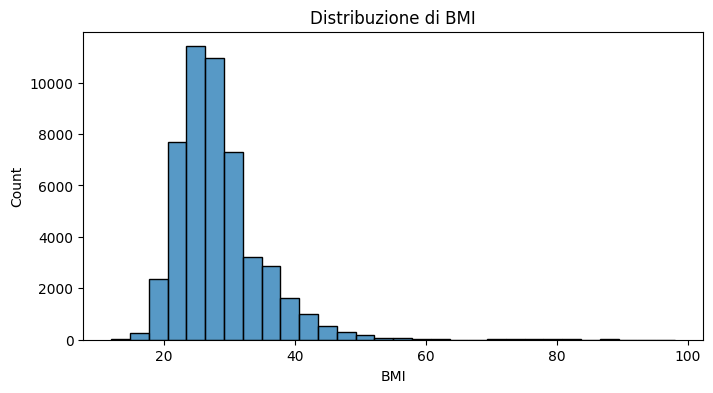

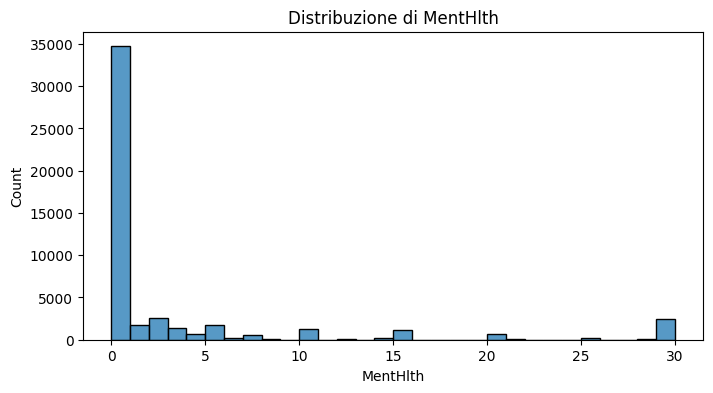

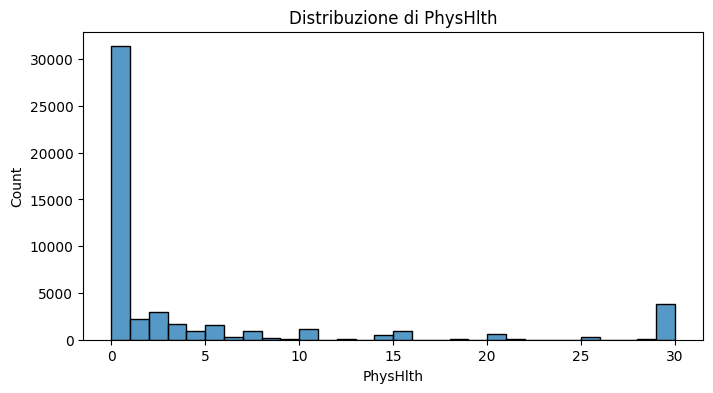

In [ ]:
# BMI
plt.figure(figsize=(8,4))
sns.histplot(training_df["BMI"], bins=30)
plt.title("Distribuzione di BMI")
plt.show()

# MentHlth
plt.figure(figsize=(8,4))
sns.histplot(training_df["MentHlth"], bins=30)
plt.title("Distribuzione di MentHlth")
plt.show()

# PhysHlth
plt.figure(figsize=(8,4))
sns.histplot(training_df["PhysHlth"], bins=30)
plt.title("Distribuzione di PhysHlth")
plt.show()


- `BMI`
Gli istogrammi mostrano una distribuzione concentrata tra 20 e 35, con pochi valori molto elevati (fino a 98).  
Questi valori estremi erano già stati identificati come potenziali outlier, ma rientrano comunque nel range previsto dal dataset CDC, quindi non rappresentano errori ma semplicemente casi rari.

- `MentHlth` e `PhysHlth`  
La forte concentrazione di valori pari a 0 e la presenza di una lunga coda verso destra confermano quanto osservato nell’analisi degli outlier:  i valori elevati (20–30 giorni) sono poco frequenti ma non anomali.

# 6. Analisi grafica

In questa sezione vengono utilizzate alcune rappresentazioni grafiche per approfondire le relazioni presenti nel dataset.

I boxplot delle principali variabili numeriche sono già stati introdotti nella fase di verifica della qualità dei dati e hanno consentito di individuare eventuali valori estremi.

L'analisi prosegue con il pairplot e con la matrice di correlazione.

## 6.1 Pairplot

Il pairplot consente di analizzare contemporaneamente la distribuzione delle variabili numeriche e le relazioni tra coppie di feature.  
La variabile `Diabetes_binary` è stata inclusa nel dataset passato al pairplot non come feature predittiva, ma per essere utilizzata come parametro `hue`, che permette di colorare i punti in base alla classe (0 = non diabetico, 1 = diabetico).

Poiché il dataset contiene 50.000 osservazioni, viene utilizzato un campione casuale di 1000 record per rendere la visualizzazione più leggibile e ridurre i tempi di elaborazione.

In [26]:
sample_df = training_df.sample(
    n=1000,
    random_state=42
)

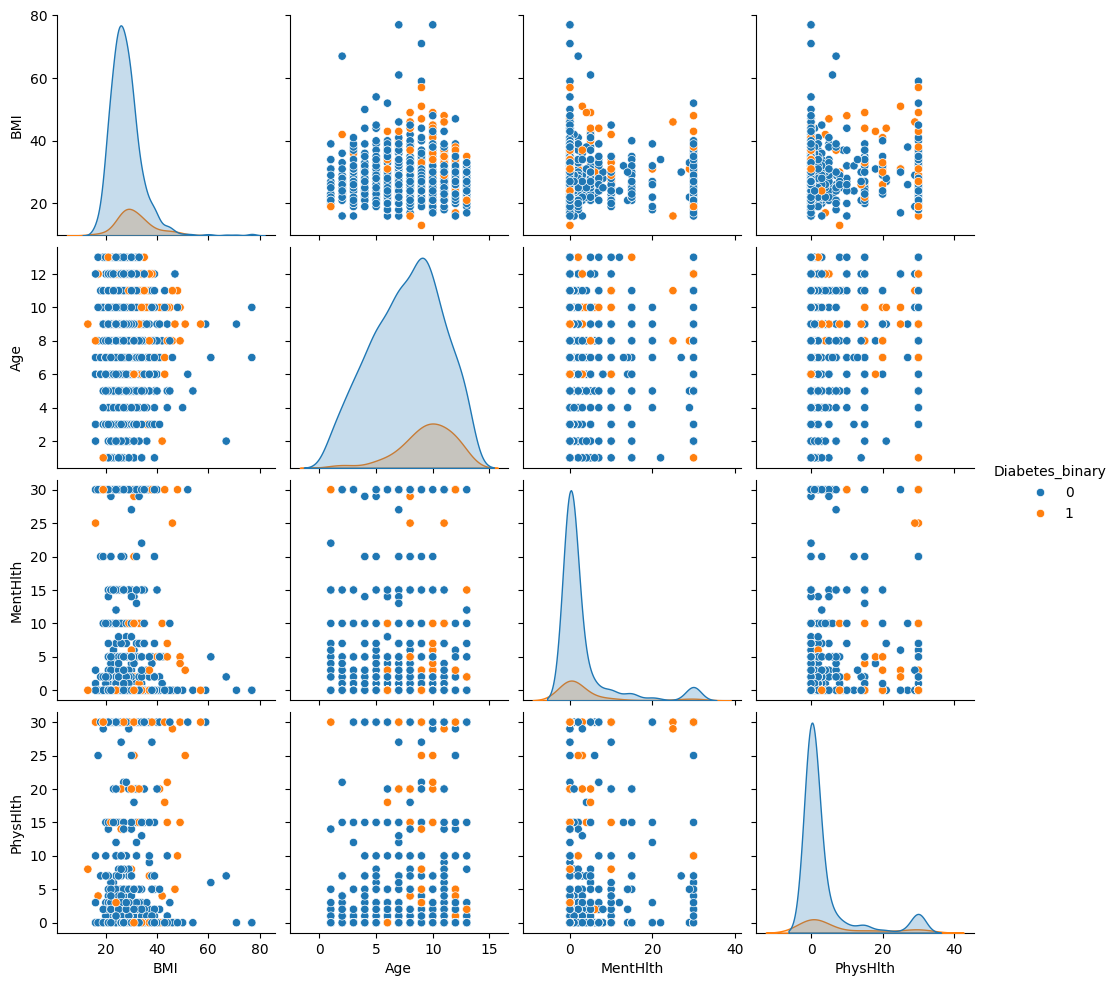

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

pairplot_features = [
    "BMI",
    "Age",
    "MentHlth",
    "PhysHlth",
    "Diabetes_binary"
]

sns.pairplot(
    sample_df[pairplot_features],
    hue="Diabetes_binary"
)

plt.show()

## Osservazioni

- Non emerge una separazione netta tra le classi: i punti appartenenti alle classi 0 e 1 risultano ampiamente sovrapposti in tutte le combinazioni di variabili.  
Questo suggerisce che le sole feature numeriche considerate non sono sufficienti per distinguere chiaramente diabetici e non diabetici.

- `BMI` mostra una distribuzione più continua e variabile rispetto alle altre feature, ma non presenta pattern distintivi tra le due classi.  
I diabetici tendono ad avere valori leggermente più alti, ma la sovrapposizione è molto ampia.

- `Age` non mostra alcuna relazione evidente con la variabile target: entrambe le classi sono distribuite in modo simile lungo l’intero intervallo dei valori.

- `MentHlth` e `PhysHlth` presentano una forte concentrazione di punti vicino allo zero, coerente con quanto osservato negli istogrammi e nei boxplot.  
Anche in questo caso non si osservano differenze significative tra le due classi.


- Le relazioni bivariate tra le feature (scatterplot fuori diagonale) non mostrano pattern lineari o cluster distinti.  
Le nuvole di punti risultano molto simili per entrambe le classi.




## 6.3 Matrice di correlazione

La correlazione misura il grado di associazione lineare tra due variabili.

Nel presente lavoro viene utilizzato il coefficiente di correlazione di Pearson, il cui valore è compreso tra -1 e +1:

- valori prossimi a +1 indicano una forte correlazione positiva;
- valori prossimi a -1 indicano una forte correlazione negativa;
- valori prossimi a 0 indicano assenza di correlazione lineare.

L'analisi della correlazione consente di individuare eventuali relazioni tra le feature e di identificare gli attributi maggiormente associati alla presenza del diabete.

In [28]:
corr_matrix = training_df.corr()

corr_matrix

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
HighBP,1.000000,0.294605,0.102790,0.214866,0.093240,0.133037,0.212226,-0.124409,-0.039073,-0.055075,...,0.016142,0.303588,0.067707,0.156212,0.220500,0.052785,0.342806,-0.137364,-0.173317,0.264060
HighChol,0.294605,1.000000,0.090896,0.109814,0.093218,0.092305,0.184011,-0.074151,-0.043287,-0.035250,...,0.010608,0.209386,0.063611,0.121071,0.142864,0.034097,0.272844,-0.070343,-0.088960,0.200424
CholCheck,0.102790,0.090896,1.000000,0.043894,-0.006316,0.029712,0.051349,0.000590,0.023249,0.011315,...,-0.049550,0.051814,-0.002743,0.036502,0.046078,-0.024885,0.098669,0.001485,0.011344,0.067900
BMI,0.214866,0.109814,0.043894,1.000000,0.011994,0.017245,0.058774,-0.144240,-0.087527,-0.063637,...,0.060900,0.238743,0.087631,0.117200,0.204914,0.043529,-0.032723,-0.103810,-0.103366,0.213851
Smoker,0.093240,0.093218,-0.006316,0.011994,1.000000,0.062627,0.115106,-0.094998,-0.076845,-0.029694,...,0.041524,0.162521,0.088842,0.111122,0.119147,0.105977,0.119527,-0.168192,-0.126978,0.060861
Stroke,0.133037,0.092305,0.029712,0.017245,0.062627,1.000000,0.200174,-0.066370,-0.012424,-0.037393,...,0.030799,0.173275,0.078807,0.148011,0.177290,0.002737,0.126865,-0.073687,-0.130562,0.106146
HeartDiseaseorAttack,0.212226,0.184011,0.051349,0.058774,0.115106,0.200174,1.000000,-0.075611,-0.016938,-0.034694,...,0.023937,0.262363,0.069780,0.183210,0.210467,0.089749,0.225417,-0.098381,-0.141169,0.190423
PhysActivity,-0.124409,-0.074151,0.000590,-0.144240,-0.094998,-0.066370,-0.075611,1.000000,0.145576,0.150475,...,-0.061833,-0.262790,-0.127768,-0.216826,-0.248656,0.033048,-0.088650,0.192124,0.202804,-0.111158
Fruits,-0.039073,-0.043287,0.023249,-0.087527,-0.076845,-0.012424,-0.016938,0.145576,1.000000,0.254469,...,-0.046314,-0.101460,-0.069331,-0.040036,-0.046100,-0.089851,0.062497,0.105228,0.079423,-0.035259
Veggies,-0.055075,-0.035250,0.011315,-0.063637,-0.029694,-0.037393,-0.034694,0.150475,0.254469,1.000000,...,-0.038103,-0.119258,-0.063843,-0.060956,-0.080857,-0.060142,-0.001721,0.153382,0.152707,-0.047884


### Heatmap della matrice di correlazione

Per facilitare l'interpretazione della matrice di correlazione viene utilizzata una heatmap.

Nella rappresentazione grafica:

- le tonalità rosse indicano correlazioni positive;
- le tonalità blu indicano correlazioni negative;
- i colori più intensi rappresentano correlazioni più forti;
- i colori vicini al bianco rappresentano correlazioni deboli o assenti.

La diagonale principale assume valore pari a 1 poiché ogni variabile è perfettamente correlata con sé stessa.

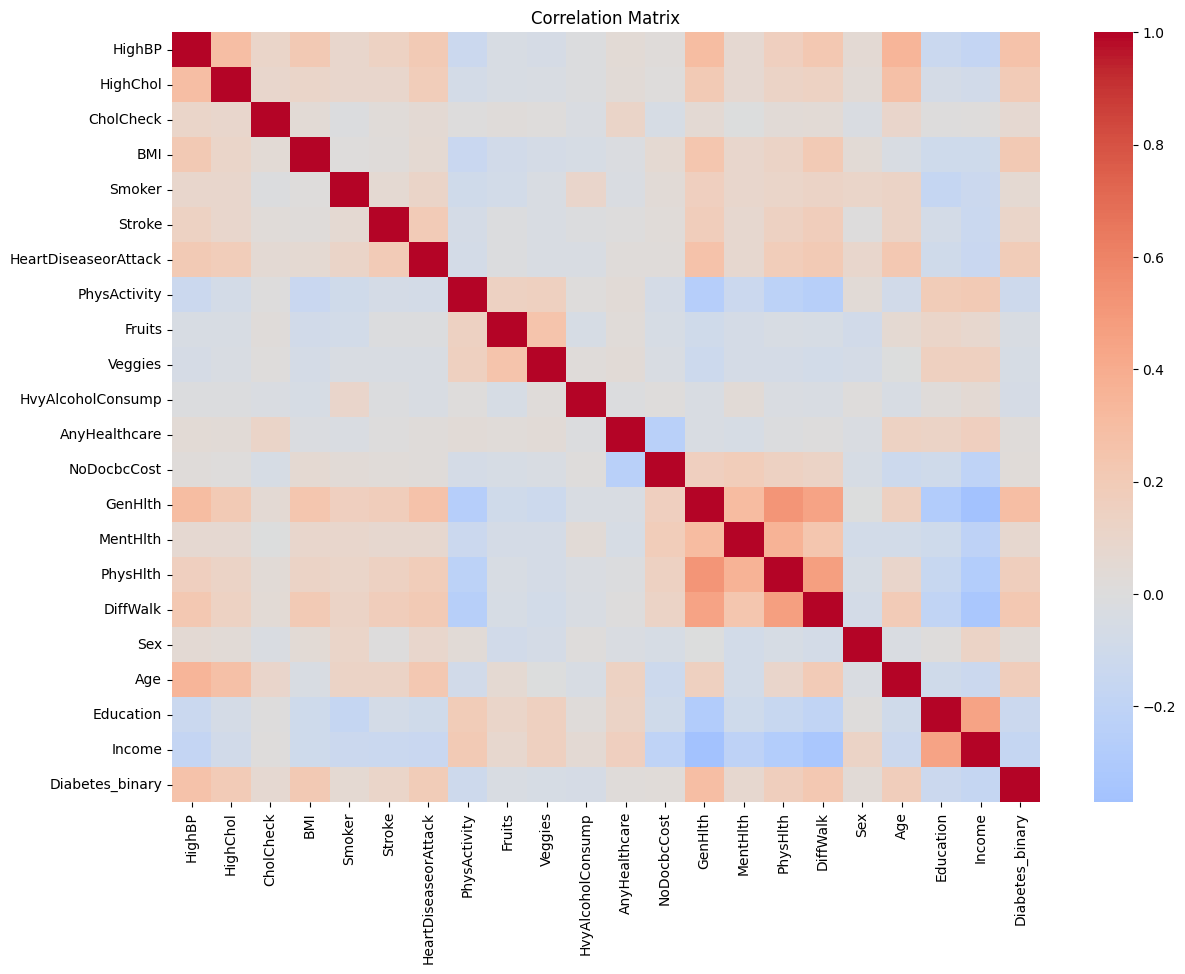

In [29]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

### Correlazione con la variabile target

Per individuare le feature più rilevanti ai fini della classificazione viene analizzata la correlazione di ciascun attributo con la variabile target `Diabetes_binary`.

Le feature vengono ordinate in funzione del valore del coefficiente di correlazione.

In [31]:
target_corr = (
    corr_matrix["Diabetes_binary"]
    .sort_values(ascending=False)
)

target_corr

Diabetes_binary         1.000000
GenHlth                 0.291017
HighBP                  0.264060
DiffWalk                0.218790
BMI                     0.213851
HighChol                0.200424
HeartDiseaseorAttack    0.190423
Age                     0.178720
PhysHlth                0.165045
Stroke                  0.106146
MentHlth                0.075607
CholCheck               0.067900
Smoker                  0.060861
Sex                     0.031346
NoDocbcCost             0.028124
AnyHealthcare           0.015782
Fruits                 -0.035259
Veggies                -0.047884
HvyAlcoholConsump      -0.058471
PhysActivity           -0.111158
Education              -0.125207
Income                 -0.165356
Name: Diabetes_binary, dtype: float64

### Rappresentazione grafica delle correlazioni

Le correlazioni con la variabile target vengono rappresentate tramite un grafico a barre orizzontali.

Questo tipo di visualizzazione consente di identificare rapidamente gli attributi maggiormente associati alla presenza del diabete.

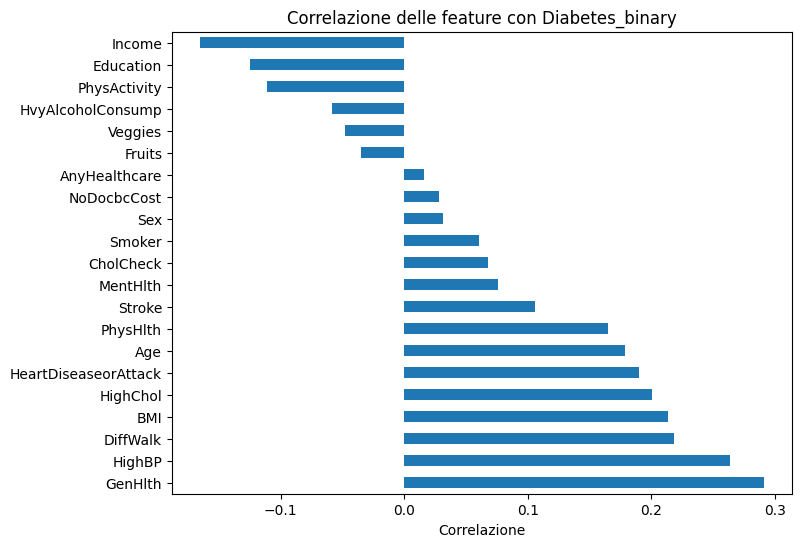

In [32]:
plt.figure(figsize=(8,6))

target_corr.drop("Diabetes_binary").plot(
    kind="barh"
)

plt.title(
    "Correlazione delle feature con Diabetes_binary"
)

plt.xlabel("Correlazione")

plt.show()

### Interpretazione delle correlazioni

L'analisi delle correlazioni con la variabile target `Diabetes_binary` evidenzia che nessuna singola feature presenta una correlazione estremamente elevata con la presenza del diabete.

La feature maggiormente correlata risulta essere `GenHlth` (0.291), seguita da:

- `HighBP` (0.264)
- `DiffWalk` (0.219)
- `BMI` (0.214)
- `HighChol` (0.200)
- `HeartDiseaseorAttack` (0.190)
- `Age` (0.179)

Tali risultati appaiono coerenti con il dominio applicativo del problema.

In particolare:

- soggetti con pressione alta tendono ad avere una maggiore probabilità di sviluppare il diabete;
- valori elevati di BMI sono associati a condizioni di sovrappeso e obesità, fattori di rischio noti;
- l'avanzamento dell'età è generalmente associato ad una maggiore incidenza della malattia;
- una peggiore percezione dello stato generale di salute (`GenHlth`) risulta associata alla presenza del diabete.

Si osservano inoltre alcune correlazioni negative.

Le più rilevanti riguardano:

- `Income` (-0.165)
- `Education` (-0.125)
- `PhysActivity` (-0.111)

Questo suggerisce che livelli più elevati di reddito, istruzione e attività fisica risultano associati ad una minore probabilità di sviluppare il diabete.

Le correlazioni osservate risultano comunque moderate. Ciò indica che il problema di classificazione non può essere risolto efficacemente utilizzando una sola feature, ma richiede la combinazione delle informazioni provenienti da più attributi.

È interessante osservare che le feature selezionate nel Task 2 per la costruzione manuale del classificatore Naive Bayes risultano tra quelle maggiormente correlate con la variabile target. Ciò conferma la ragionevolezza della selezione effettuata nella fase iniziale del progetto.

# 7. Considerazioni finali

L'analisi esplorativa del dataset `training.csv` ha consentito di verificare la qualità dei dati e di comprendere meglio le caratteristiche delle osservazioni disponibili.

In particolare è stato verificato che:

- non sono presenti valori mancanti;
- i range delle variabili risultano coerenti con la documentazione ufficiale del dataset;
- sono presenti osservazioni duplicate, ma tali duplicati rappresentano individui differenti che condividono le stesse caratteristiche e pertanto sono stati mantenuti;
- non sono emersi valori palesemente errati nelle feature analizzate.

L'analisi della variabile target ha evidenziato un marcato sbilanciamento delle classi, con una prevalenza di soggetti non diabetici rispetto ai soggetti diabetici. Questa caratteristica dovrà essere considerata nella valutazione dei classificatori, affiancando all'accuracy metriche più informative quali precision, recall e F1-score.

L'analisi grafica tramite boxplot ha mostrato la presenza di valori estremi in alcune variabili numeriche, in particolare BMI, MentHlth e PhysHlth. Tuttavia tali valori risultano compatibili con il dominio applicativo e non sono stati considerati errori di registrazione.

L'analisi delle correlazioni ha evidenziato che le feature maggiormente associate alla presenza del diabete sono:

- GenHlth;
- HighBP;
- DiffWalk;
- BMI;
- HighChol;
- Age.

Le correlazioni osservate risultano comunque moderate, suggerendo che nessuna singola variabile sia sufficiente per discriminare efficacemente le due classi.

Questo risultato conferma la necessità di utilizzare modelli di Machine Learning in grado di combinare simultaneamente l'informazione proveniente da più feature.

Infine, è interessante osservare che alcune delle variabili selezionate nel Task 2 per la costruzione manuale del classificatore Naive Bayes (HighBP, HighChol, BMI, Age e PhysActivity) risultano tra quelle maggiormente correlate con la variabile target, confermando la validità della scelta effettuata.

Le informazioni ottenute in questa fase saranno utilizzate nei successivi task per addestrare e valutare differenti classificatori sul dataset di training.